## Objective
The objective of this exercise is to apply K-Means clustering to group cars with similar technical and fuel-efficiency characteristics. The dataset will be prepared and standardised before testing different values of K. Inertia will be used as the main measure for cluster selection, while the Silhouette Score will provide additional support. The value `max_drop_K` will be used to identify the number of clusters associated with the largest decrease in inertia. The final clusters will then be interpreted and visualised using suitable feature-based and dimensionality-reduction methods.

In [1]:
import os  # import os to set an environment variable for consistent CPU usage
import warnings  # import warnings to control unnecessary warning messages
os.environ['LOKY_MAX_CPU_COUNT'] = '1'  # limit the number of CPU workers used by K-Means
warnings.filterwarnings('ignore')  # hide warning messages to keep the notebook output clear
import numpy as np  # import NumPy to work with arrays and count cluster observations
import pandas as pd  # import pandas to load, inspect, and organise the dataset
import matplotlib.pyplot as plt  # import Matplotlib to create the clustering visualisations
from sklearn.cluster import KMeans  # import KMeans to create groups of similar cars
from sklearn.preprocessing import StandardScaler  # import StandardScaler to place all features on a common scale
from sklearn.manifold import TSNE  # import t-SNE to represent the clusters in two dimensions
from sklearn.decomposition import PCA  # import PCA to represent the clusters using principal components
from sklearn.metrics import silhouette_score  # import Silhouette Score to evaluate how well-separated the clusters are

In [2]:
# Load the car price dataset into a pandas DataFrame.
X = pd.read_csv('carprices_dataset.csv'); X.sample(2)

,enginesize,horsepower,citympg,highwaympg
12,164,121,21,28
40,110,86,27,33


In [3]:
# Check the number of rows and columns in the dataset
X.shape

(205, 4)

In [4]:
# Review the column names, data types, and non-null values
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   enginesize  205 non-null    int64
 1   horsepower  205 non-null    int64
 2   citympg     205 non-null    int64
 3   highwaympg  205 non-null    int64
dtypes: int64(4)
memory usage: 6.5 KB


In [5]:
# Display summary statistics for all numerical features
X.describe() 

,enginesize,horsepower,citympg,highwaympg
count,205.000000,205.000000,205.000000,205.000000
mean,126.907317,104.117073,25.219512,30.751220
std,41.642693,39.544167,6.542142,6.886443
min,61.000000,48.000000,13.000000,16.000000
25%,97.000000,70.000000,19.000000,25.000000
50%,120.000000,95.000000,24.000000,30.000000
75%,141.000000,116.000000,30.000000,34.000000
max,326.000000,288.000000,49.000000,54.000000


# Task 1
### Feature Scaling
- Scale all features using `StandardScaler()` from `sklearn.preprocessing`

In [6]:
# Create the StandardScaler object
scaler = StandardScaler(); X_scaled = scaler.fit_transform(X)

# Task 2
### Clustering for Various Values of K
- Apply K-Means clustering to the scaled data using `KMeans()` from `sklearn.cluster` with `init = 'random'`, `random_state = 9001`, and `n_init = 10`
- Compute and analyse the inertia or WCSS and the silhouette score for values of K from 2 to 10
- Calculate the decrease in inertia between consecutive K values and store the K value associated with the largest decrease as `max_drop_K.`
- Visualise and compare inertia and Silhouette Score for different values of K using subplots

In [7]:
# Test K-Means models from K = 2 to K = 10 and store their evaluation results
k_values = range(2, 11); inertia_values = []; silhouette_scores = []; cluster_sizes = []
for k in k_values:
    kmeans = KMeans(n_clusters = k, init = 'random', random_state = 9001, n_init = 10)
    labels = kmeans.fit_predict(X_scaled)
    inertia_values.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))
    cluster_sizes.append(np.bincount(labels, minlength=k))
# Organise the K values, inertia, Silhouette Scores, and cluster sizes into a DataFrame
results = pd.DataFrame({'K': list(k_values),
                        'Inertia': inertia_values,
                        'Silhouette Score': silhouette_scores,
                        'Size': cluster_sizes}).set_index('K')
results

,Inertia,Silhouette Score,Size
K,,,
2,385.230909,0.470819,"[85, 120]"
3,234.453666,0.453655,"[61, 98, 46]"
4,174.141190,0.433666,"[15, 41, 88, 61]"
5,137.294351,0.429213,"[52, 15, 46, 75, 17]"
6,111.621291,0.414808,"[15, 46, 63, 17, 33, 31]"
7,101.551570,0.414995,"[3, 49, 15, 45, 45, 33, 15]"
8,84.802194,0.432977,"[8, 45, 33, 56, 3, 15, 38, 7]"
9,72.773468,0.454007,"[23, 8, 45, 31, 54, 3, 15, 19, 7]"
10,67.389903,0.413227,"[21, 23, 12, 26, 45, 3, 14, 24, 3, 34]"


In [8]:
# Calculate the decrease in inertia and identify the value of K with the largest drop
drops = results['Inertia'].shift(1) - results['Inertia']; max_drop_K = drops.idxmax(); max_drop_value = drops.loc[max_drop_K]
print(max_drop_K, 'and', max_drop_value)

3 and 150.777243279161


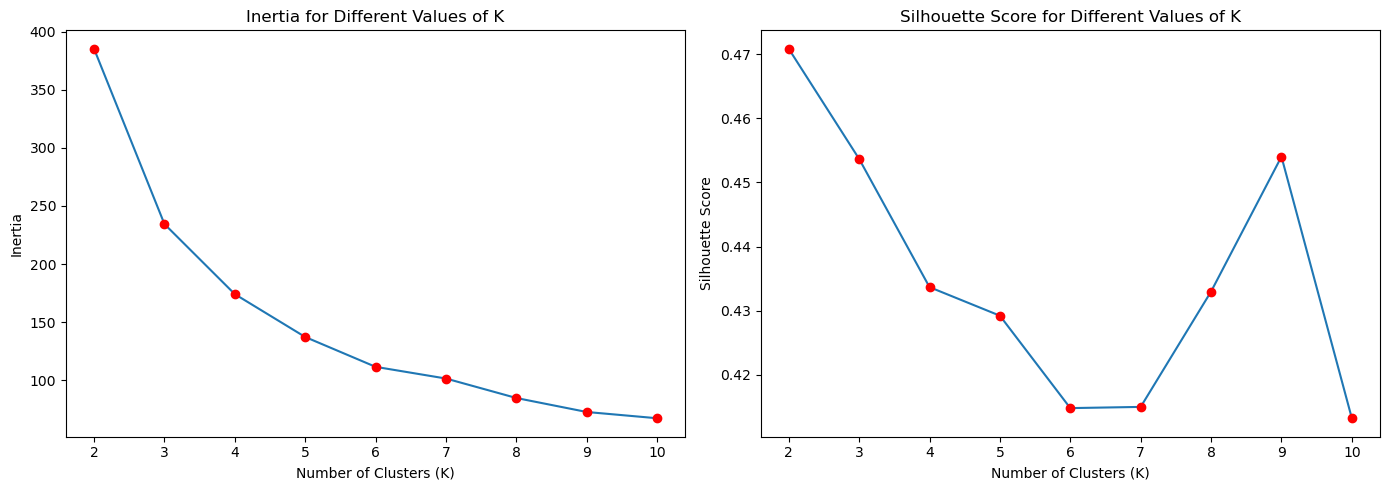

In [9]:
# Visualise inertia and Silhouette Score for different values of K
fig, axes = plt.subplots(1, 2, figsize = (14, 5))
axes[0].plot(results.index, results['Inertia'], marker = 'o', markerfacecolor = 'red', markeredgecolor = 'red')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia');axes[0].set_title('Inertia for Different Values of K')
axes[0].set_xticks(results.index)
axes[1].plot(results.index, results['Silhouette Score'], marker = 'o', markerfacecolor = 'red', markeredgecolor = 'red')
axes[1].set_xlabel('Number of Clusters (K)');axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score for Different Values of K')
axes[1].set_xticks(results.index)
plt.tight_layout()
plt.show()

# Task 3: Build and Interpret the Clusters

- Build the final K-Means model using `KMeans()` with `n_clusters = max_drop_K`, `init = 'random'`, `random_state = 9001`, and `n_init = 10`
- Assign each observation to a cluster
- Display the number of observations in each cluster
- Inverse transform the cluster centroids back to the original feature scale
- Compare the centroid values to understand the differences between the three groups of cars
- Assign a meaningful and subjective label to each cluster based on engine size, horsepower, city mileage, and highway mileage

In [10]:
# Build the final K-Means model using max_drop_K
final_kmeans = KMeans(n_clusters = max_drop_K, init = 'random', random_state = 9001, n_init = 10)
cluster_labels = final_kmeans.fit_predict(X_scaled);centroids_scaled = final_kmeans.cluster_centers_
print('Final number of clusters:', max_drop_K)
# Display the number of observations in each cluster
cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()
print('Number of observations in each cluster:');print(cluster_counts)

Final number of clusters: 3
Number of observations in each cluster:
0    61
1    98
2    46
Name: count, dtype: int64


In [11]:
# Transform the cluster centroids back to the original feature scale
centroids_original = scaler.inverse_transform(centroids_scaled)
centroid_summary = pd.DataFrame(centroids_original, columns = X.columns)
centroid_summary.insert(0, 'Cluster', range(1, max_drop_K + 1));centroid_summary.round(2)

,Cluster,enginesize,horsepower,citympg,highwaympg
0,1,95.25,67.34,33.13,38.97
1,2,120.21,98.87,23.72,29.26
2,3,183.15,164.07,17.91,23.04


In [12]:
# Assign meaningful labels to the clusters based on their centroid values
cluster_order = centroid_summary.sort_values(by = ['enginesize', 'horsepower'])['Cluster'].tolist()
cluster_name_map = {cluster_order[0]: 'Compact and Fuel-Efficient Cars',cluster_order[1]: 'Balanced Mid-Range Cars',cluster_order[2]: 'Powerful and Lower-Efficiency Cars'}
centroid_summary['Cluster Label'] = centroid_summary['Cluster'].map(cluster_name_map)
centroid_summary = centroid_summary[['Cluster', 'Cluster Label', 'enginesize', 'horsepower', 'citympg', 'highwaympg']]
centroid_summary.round(2)

,Cluster,Cluster Label,enginesize,horsepower,citympg,highwaympg
0,1,Compact and Fuel-Efficient Cars,95.25,67.34,33.13,38.97
1,2,Balanced Mid-Range Cars,120.21,98.87,23.72,29.26
2,3,Powerful and Lower-Efficiency Cars,183.15,164.07,17.91,23.04


In [13]:
# Add the cluster number and meaningful label to the original dataset
clustered_cars = X.copy();clustered_cars['Cluster'] = cluster_labels + 1
clustered_cars['Cluster Label'] = clustered_cars['Cluster'].map(cluster_name_map);clustered_cars.head()

,enginesize,horsepower,citympg,highwaympg,Cluster,Cluster Label
0,130,111,21,27,2,Balanced Mid-Range Cars
1,130,111,21,27,2,Balanced Mid-Range Cars
2,152,154,19,26,3,Powerful and Lower-Efficiency Cars
3,109,102,24,30,2,Balanced Mid-Range Cars
4,136,115,18,22,2,Balanced Mid-Range Cars


# Task 4: Visualise the Clusters
- Visualise the K-Means clusters using the original engine size and horsepower values
- Display the cluster centroids on the graph

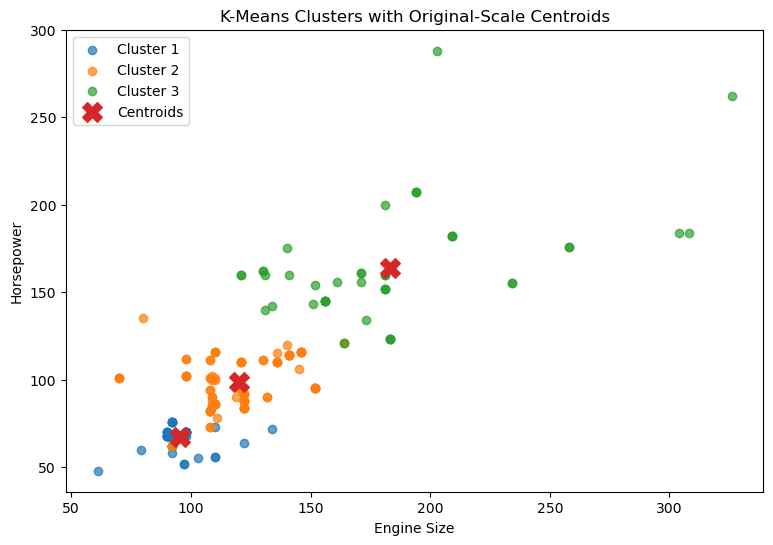

In [14]:
# Visualise the K-Means clusters and centroids using original engine size and horsepower values
engine_size_index = X.columns.get_loc('enginesize');horsepower_index = X.columns.get_loc('horsepower')
plt.figure(figsize = (9 , 6))
for cluster in range(max_drop_K):
    cluster_points = cluster_labels == cluster
    plt.scatter(X.loc[cluster_points , 'enginesize'], X.loc[cluster_points , 'horsepower'], label = 'Cluster ' + str(cluster + 1), alpha = 0.7)
plt.scatter(centroids_original[: , engine_size_index], centroids_original[:, horsepower_index], marker = 'X', s = 200, label = 'Centroids')
plt.xlabel('Engine Size');plt.ylabel('Horsepower');plt.title('K-Means Clusters with Original-Scale Centroids')
plt.legend()
plt.show()

# Task 5: Visualise the Clusters Using t-SNE
- Apply t-SNE using `n_components = 2`, `random_state = 9001`, `perplexity = 30`, `init = 'pca'`, and `learning_rate = 'auto'`
- Visualise the K-Means clusters using the two t-SNE components

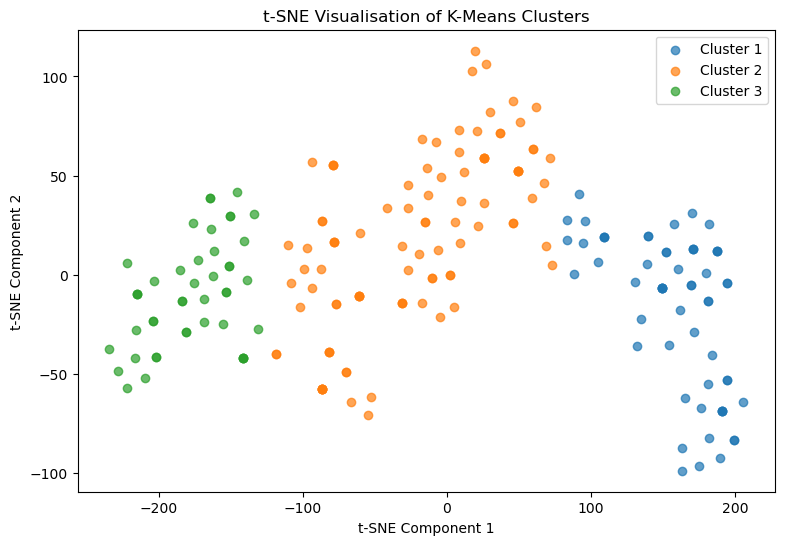

In [15]:
# Apply t-SNE and visualise the K-Means clusters in two dimensions.
tsne = TSNE(n_components = 2, random_state = 9001, perplexity = 30, init = 'pca', learning_rate = 'auto')
X_tsne = tsne.fit_transform(X_scaled)
plt.figure(figsize = (9, 6))
for cluster in range(max_drop_K):
    plt.scatter(X_tsne[cluster_labels == cluster, 0], X_tsne[cluster_labels == cluster, 1], label = 'Cluster ' + str(cluster + 1), alpha = 0.7)
plt.xlabel('t-SNE Component 1');plt.ylabel('t-SNE Component 2');plt.title('t-SNE Visualisation of K-Means Clusters')
plt.legend()
plt.show()

# Task 6: Visualise the Clusters Using PCA
- Apply PCA with `n_components=2` to transform the scaled observations and scaled cluster centroids into two dimensions
- Visualise the K-Means clusters and their centroids using the two principal components

In [16]:
# Apply PCA and transform the observations and centroids into two dimensions
pca = PCA(n_components = 2)
X_pca = pca.fit_transform(X_scaled);centroids_pca = pca.transform(centroids_scaled)

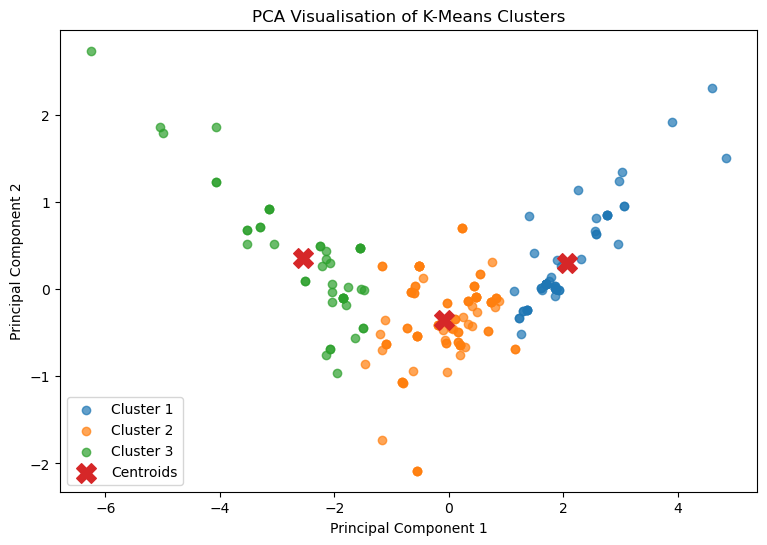

In [17]:
# Visualise the K-Means clusters and centroids using PCA
plt.figure(figsize = (9 , 6))
for cluster in range(max_drop_K):
    plt.scatter(X_pca[cluster_labels == cluster , 0], X_pca[cluster_labels == cluster , 1], label = 'Cluster ' + str(cluster + 1), alpha = 0.7)
plt.scatter(centroids_pca[: , 0], centroids_pca[: , 1] , marker = 'X', s = 200, label = 'Centroids')
plt.xlabel('Principal Component 1');plt.ylabel('Principal Component 2')
plt.title('PCA Visualisation of K-Means Clusters')
plt.legend()
plt.show()